# MLE analysis

In [1]:
import sys
sys.path.append("../")

from config import *

In [2]:
import joblib
df = joblib.load(projdir + '/results/stats/grf_collected_stats_sheet_sill-normalized_all_runs.pkl')

In [3]:
print(np.corrcoef(df['mae_sampling'], df['mae_modeling'])[1,0])
print(np.corrcoef(df['mae_modeling'], df['uneven_z'])[1,0])
print(np.corrcoef(df['mae_sampling'], df['uneven_z'])[1,0])

-0.8303945779482139
0.012958065333734111
0.02525890724983112


In [4]:
scatter_aes = {"edgecolor": 'none', "alpha":0.3, "s": 10, "rasterized":True, "legend":False}

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get an existing colormap and sample a segment
lincmap = plt.get_cmap('Blues')
range_colours = lincmap(np.linspace(0.4, .7, len(test_percentages)))
lincmap = plt.get_cmap('YlOrBr')
pct_colours = lincmap(np.linspace(0.3, .6, len(test_percentages)))

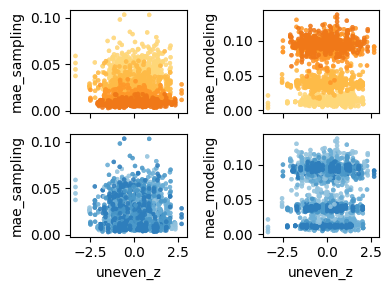

In [6]:
import seaborn as sns

fig, axs = plt.subplots(2,2, figsize = (4,3), sharex=True)

sns.scatterplot(df, y='mae_sampling', x='uneven_z', hue = 'percentage', palette= list(pct_colours), \
                **scatter_aes, ax=axs[0,0])

sns.scatterplot(df, y='mae_modeling', x='uneven_z', hue = 'percentage', palette= list(pct_colours), \
                **scatter_aes, ax=axs[0,1])

sns.scatterplot(df, y='mae_sampling', x='uneven_z', hue = 'range', palette= list(range_colours), \
                **scatter_aes, ax=axs[1,0])

sns.scatterplot(df, y='mae_modeling', x='uneven_z', hue = 'range', palette= list(range_colours), \
                **scatter_aes, ax=axs[1,1])

plt.tight_layout()

In [7]:
import statsmodels.formula.api as smf

df["percentage"] = df["percentage"].astype("category")
df["range"] = df["range"].astype("category")
df["approach"] = df["approach"].astype("category")

In [8]:
df.head()

,rank,approach,percentage,range,mae_sampling,mae_modeling,uneven_z
0,1.000000,regkrige,5,25,0.046677,0.006267,0.913761
1,0.809524,swr,5,25,0.046677,0.006267,0.913761
2,0.595238,krige,5,25,0.046677,0.006267,0.913761
3,0.500000,idw,5,25,0.046677,0.006267,0.913761
4,0.428571,knn,5,25,0.046677,0.006267,0.913761


In [9]:
formulas = ( "mae_sampling ~ uneven_z * ( C(percentage) + C(range) )",\
             "mae_modeling ~ uneven_z * ( C(percentage) + C(range) )" ,\
             "rank ~ mae_sampling +  uneven_z * ( C(approach) + C(percentage) + C(range) )",\
             "rank ~ mae_modeling * (C(approach) + C(percentage) + C(range))")

In [10]:
mdl0 = smf.ols(formulas[0], data=df).fit(cov_type="HC3")
mdl1 = smf.ols(formulas[1], data=df).fit(cov_type="HC3")
mdl2 = smf.ols(formulas[2], data=df).fit(cov_type="HC3")


In [11]:
print(mdl0.summary())

                            OLS Regression Results                            
Dep. Variable:           mae_sampling   R-squared:                       0.790
Model:                            OLS   Adj. R-squared:                  0.790
Method:                 Least Squares   F-statistic:                     3233.
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        12:16:47   Log-Likelihood:                 33165.
No. Observations:                9600   AIC:                        -6.630e+04
Df Residuals:                    9586   BIC:                        -6.620e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [12]:
mdl0.pvalues

Intercept                       0.000000e+00
C(percentage)[T.10]             0.000000e+00
C(percentage)[T.25]             0.000000e+00
C(percentage)[T.50]             0.000000e+00
C(range)[T.50]                  8.291019e-08
C(range)[T.75]                  2.554335e-03
C(range)[T.100]                 6.398059e-09
uneven_z                        2.839435e-04
uneven_z:C(percentage)[T.10]    1.200867e-03
uneven_z:C(percentage)[T.25]    6.728691e-05
uneven_z:C(percentage)[T.50]    5.829235e-04
uneven_z:C(range)[T.50]         9.910020e-01
uneven_z:C(range)[T.75]         3.047353e-01
uneven_z:C(range)[T.100]        4.186594e-02
dtype: float64

In [13]:
from statsmodels.stats.multitest import multipletests

p_values = mdl0.pvalues
reject, corrected_pvalues, _, _ = multipletests(p_values, method='bonferroni')
corrected_pvalues

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.16074261e-06, 3.57606901e-02, 8.95728275e-08, 3.97520848e-03,
       1.68121380e-02, 9.42016790e-04, 8.16092860e-03, 1.00000000e+00,
       1.00000000e+00, 5.86123090e-01])

In [14]:
print(mdl1.summary())

                            OLS Regression Results                            
Dep. Variable:           mae_modeling   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.643e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        12:17:51   Log-Likelihood:                 31639.
No. Observations:                9600   AIC:                        -6.325e+04
Df Residuals:                    9586   BIC:                        -6.315e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

In [15]:
mdl1.pvalues

Intercept                       0.000000e+00
C(percentage)[T.10]             0.000000e+00
C(percentage)[T.25]             0.000000e+00
C(percentage)[T.50]             0.000000e+00
C(range)[T.50]                  9.162706e-10
C(range)[T.75]                  2.573555e-32
C(range)[T.100]                 1.954907e-39
uneven_z                        1.621830e-07
uneven_z:C(percentage)[T.10]    6.878243e-01
uneven_z:C(percentage)[T.25]    1.341351e-01
uneven_z:C(percentage)[T.50]    2.980312e-01
uneven_z:C(range)[T.50]         1.373900e-02
uneven_z:C(range)[T.75]         7.902483e-05
uneven_z:C(range)[T.100]        2.853257e-06
dtype: float64

In [16]:
from statsmodels.stats.multitest import multipletests

p_values = mdl1.pvalues
reject, corrected_pvalues, _, _ = multipletests(p_values, method='bonferroni')
corrected_pvalues

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       1.28277877e-08, 3.60297694e-31, 2.73686971e-38, 2.27056224e-06,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.92345957e-01,
       1.10634760e-03, 3.99456037e-05])

In [17]:
print(mdl2.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     772.1
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        12:17:56   Log-Likelihood:                 3365.0
No. Observations:                9600   AIC:                            -6680.
Df Residuals:                    9575   BIC:                            -6501.
Df Model:                          24                                         
Covariance Type:                  HC3                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

In [18]:
mdl2.pvalues

Intercept                           0.000000e+00
C(approach)[T.knn]                  3.565674e-33
C(approach)[T.krige]                0.000000e+00
C(approach)[T.rbf]                  0.000000e+00
C(approach)[T.regkrige]             0.000000e+00
C(approach)[T.swr]                  1.977393e-43
C(percentage)[T.10]                 1.000000e+00
C(percentage)[T.25]                 1.000000e+00
C(percentage)[T.50]                 1.000000e+00
C(range)[T.50]                      1.000000e+00
C(range)[T.75]                      1.000000e+00
C(range)[T.100]                     1.000000e+00
mae_sampling                        1.000000e+00
uneven_z                            6.649875e-01
uneven_z:C(approach)[T.knn]         1.218404e-01
uneven_z:C(approach)[T.krige]       4.357283e-01
uneven_z:C(approach)[T.rbf]         1.832359e-01
uneven_z:C(approach)[T.regkrige]    5.543279e-01
uneven_z:C(approach)[T.swr]         9.945361e-01
uneven_z:C(percentage)[T.10]        1.000000e+00
uneven_z:C(percentag

In [19]:
from statsmodels.stats.multitest import multipletests

p_values = mdl2.pvalues
reject, corrected_pvalues, _, _ = multipletests(p_values, method='bonferroni')
corrected_pvalues

array([0.00000000e+00, 8.91418419e-32, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 4.94348146e-42, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
       1.00000000e+00])

In [23]:
from figs_config import *

Loaded aesthetics module


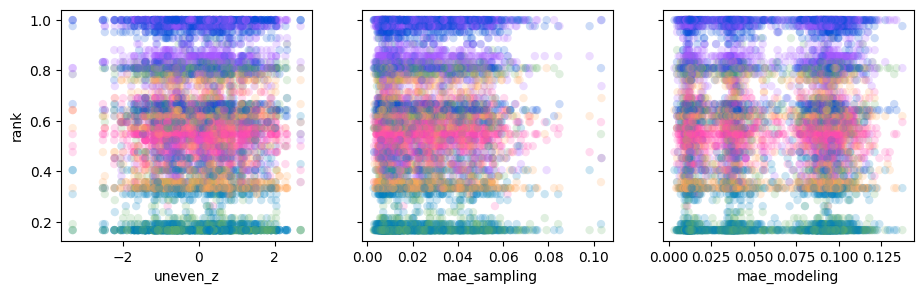

In [25]:
fig, axs = plt.subplots(1,3, figsize = (11, 3), sharey=True)

sns.scatterplot(
    data=df,
    x="uneven_z",
    y="rank",
    hue="approach",
    alpha=0.2,
    edgecolor = 'none',
    palette=apal,
    legend=False,
    rasterized=True,
    ax=axs[0]
)

sns.scatterplot(
    data=df,
    x="mae_sampling",
    y="rank",
    hue="approach",
    alpha=0.2,
    edgecolor = 'none',
    palette = apal,
    legend=False,
    rasterized=True,
    ax=axs[1]
)

sns.scatterplot(
    data=df,
    x="mae_modeling",
    y="rank",
    hue="approach",
    alpha=0.2,
    edgecolor = 'none',
    palette = apal,
    legend=False,
    rasterized=True,
    ax=axs[2]
)
plt.show()

(0.0, 1.0)

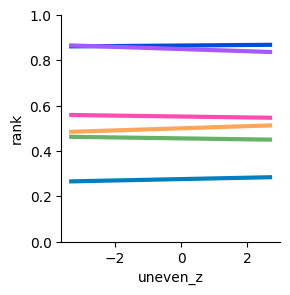

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

#plt.figure(figsize = (5,5))

sns.lmplot(
    data=df,
    x="uneven_z",
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)

#plt.show()
plt.ylim([0,1])

(0.0, 1.0)

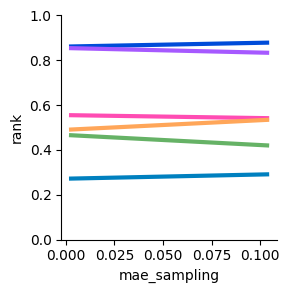

In [27]:
sns.lmplot(
    data=df,
    x="mae_sampling",
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])

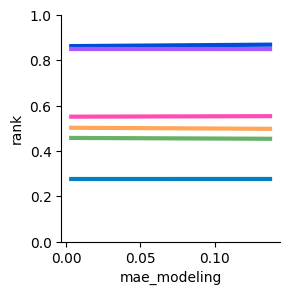

In [30]:
sns.lmplot(
    data=df,
    x="mae_modeling",
    y="rank",
    hue="approach",
    col_wrap=None,
    ci=None,
    scatter=False,
    line_kws={"linewidth": 3},
    palette = apal,\
    legend=False,
    height = 3, aspect = 1
)
plt.ylim([0,1])
plt.show()

# ordinary vs. regression kriging

In [28]:
df_kr = df[df['approach'].isin(['krige', 'regkrige'])]

In [34]:
df_kr.head()

,rank,approach,percentage,range,mae_sampling,mae_modeling,uneven_z
0,1.000000,regkrige,5,25,0.046677,0.006267,0.913761
2,0.595238,krige,5,25,0.046677,0.006267,0.913761
6,1.000000,regkrige,5,25,0.056644,0.033178,0.913761
8,0.690476,krige,5,25,0.056644,0.033178,0.913761
12,1.000000,regkrige,5,25,0.063342,0.007128,0.913761


In [29]:
mdl3 = smf.ols(formulas[3], data=df_kr).fit(cov_type="HC3")
print(mdl3.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5884
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.886
Time:                        12:02:39   Log-Likelihood:                 1280.5
No. Observations:                3200   AIC:                            -2529.
Df Residuals:                    3184   BIC:                            -2432.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


In [35]:
bad = df_kr["mae_modeling"].quantile(0.9) # top 10% MAE being especially bad fit
df_kr["mae_bad"] = df_kr["mae_modeling"] - bad

m_bad = smf.ols(
    "rank ~ mae_bad * ( C(approach) + C(percentage) + C(range) )",
    data=df_kr
).fit(cov_type="HC3")
print(m_bad.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.5884
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.886
Time:                        12:04:43   Log-Likelihood:                 1280.5
No. Observations:                3200   AIC:                            -2529.
Df Residuals:                    3184   BIC:                            -2432.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

(0.8, 1.0)

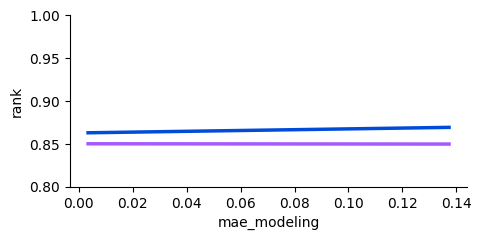

In [37]:
import seaborn as sns

g=sns.lmplot(
    data=df,
    x="mae_modeling",
    y="rank",
    hue="approach",        # krige vs regkrige
    ci=None,
    scatter=False,
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.5},
    aspect = 2, height = 2.5
)
plt.ylim([.8, 1])

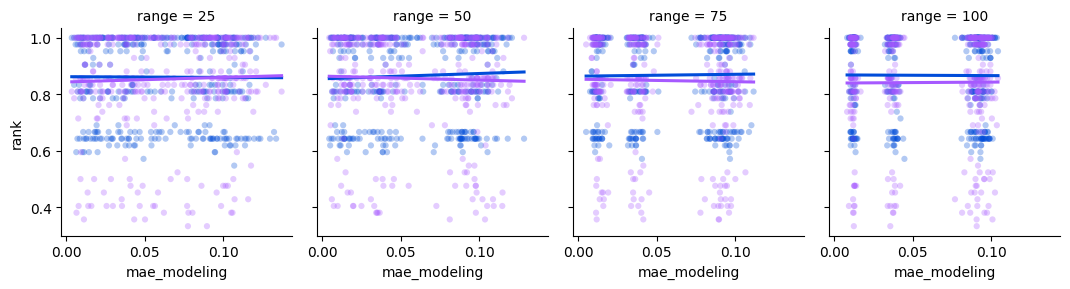

In [39]:
sns.lmplot(
    data=df,
    x="mae_modeling",
    y="rank",
    hue="approach",
    col="range",      # or col="range"
    col_wrap=len(test_ranges),
    ci=None,
    scatter_kws={
        "alpha": 0.3,
        "s": 20,
        "edgecolor": "none"
    },
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.2},
    aspect = .9, height = 3
)
plt.show()

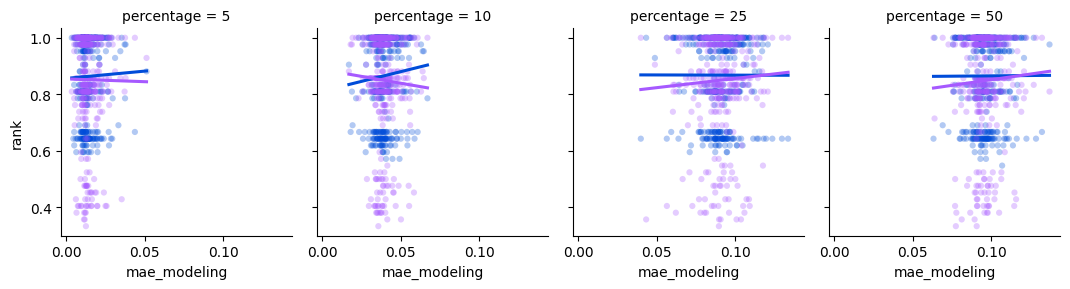

In [40]:
sns.lmplot(
    data=df,
    x="mae_modeling",
    y="rank",
    hue="approach",
    col="percentage",      # or col="range"
    col_wrap=len(test_percentages),
    ci=None,
    scatter_kws={
        "alpha": 0.3,
        "s": 20,
        "edgecolor": "none"
    },
    palette=apal,
    legend=False,
    line_kws={"linewidth": 2.2},
    aspect = .9, height = 3
)
plt.show()